# Testing RCWA calculations when scaling the grating

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append('../')

import torch

import autolib 
import fom
from parameters import D1_ND, Parameters
from twobox import TwoBox
from ilic import *

npa = autolib.AutoLib('torch')
npaa = autolib.AutoLib('autograd')

# Ilic grating

In [2]:
 ## Ilic
wavelength      = 1.5 #/ D1_ND(1.2/100)
grating_pitch   = 1.8 / wavelength
grating_depth   = 0.5 / wavelength
box1_width      = 0.15 * grating_pitch
box2_width      = 0.35 * grating_pitch
box_centre_dist = 0.60 * grating_pitch
box1_eps        = 3.5**2 
box2_eps        = 3.5**2
gaussian_width  = 2* 10   # 2.7180049942915896 * 10
substrate_depth = 0.5 / wavelength
substrate_eps   = 1.45**2

wavelength      = 1.
angle           = 0.
Nx              = 300
numG            = 12
Qabs            = np.inf

gratingGRCWA = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, numG, Qabs, RCWA_engine='GRCWA')
numGTorcwa = numG
gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, numGTorcwa, Qabs, RCWA_engine='TORCWA',torcwa_edge_sharpness=45)

# Qpr2 testing

tensor(0.9000, dtype=torch.float64, requires_grad=True)
tensor(0.9222, dtype=torch.float64, requires_grad=True)
tensor(0.9444, dtype=torch.float64, requires_grad=True)
tensor(0.9667, dtype=torch.float64, requires_grad=True)
tensor(0.9889, dtype=torch.float64, requires_grad=True)
tensor(1.0111, dtype=torch.float64, requires_grad=True)
tensor(1.0333, dtype=torch.float64, requires_grad=True)
tensor(1.0556, dtype=torch.float64, requires_grad=True)
tensor(1.0778, dtype=torch.float64, requires_grad=True)
tensor(1.1000, dtype=torch.float64, requires_grad=True)


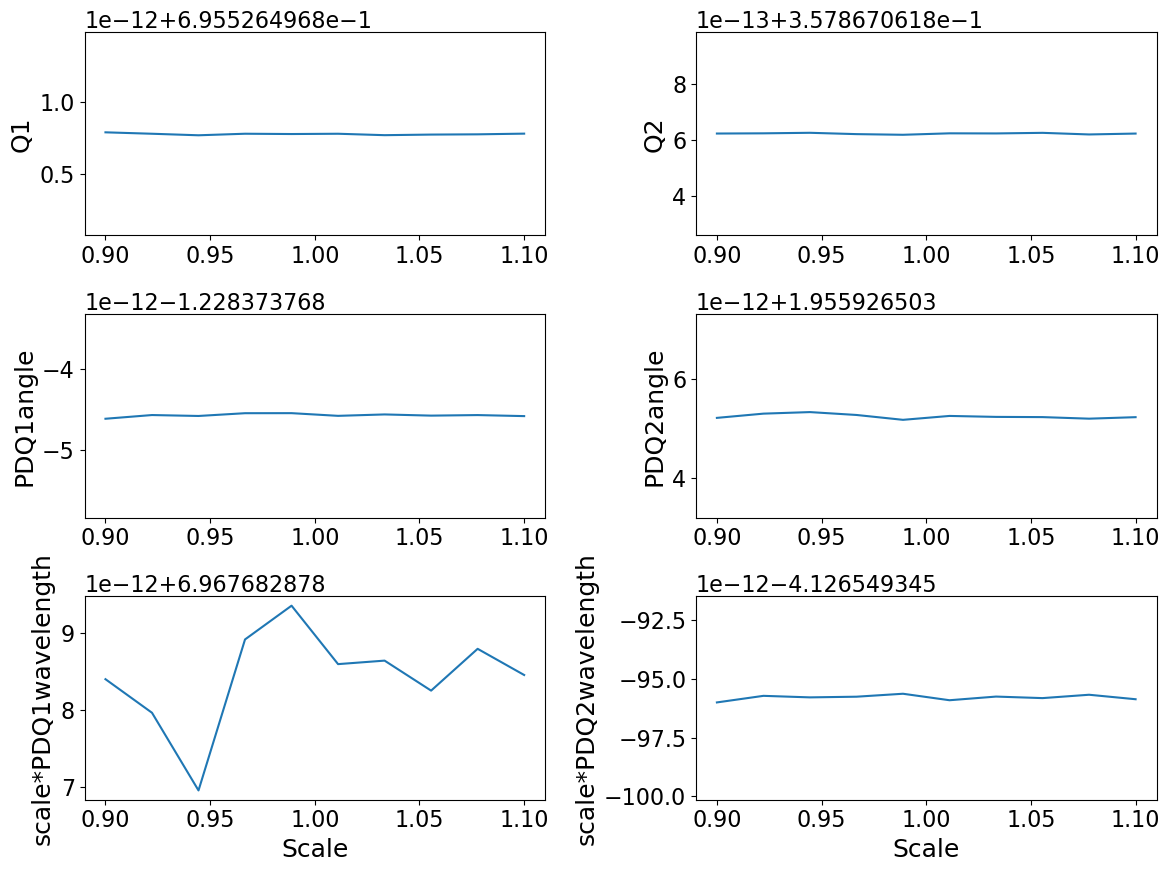

In [6]:
from copy import deepcopy as deepcopy

gratingTorcwa = TwoBox(grating_pitch, grating_depth, box1_width, box2_width, box_centre_dist, box1_eps, box2_eps, 
                 gaussian_width, substrate_depth, substrate_eps,
                 wavelength, angle, Nx, 12, Qabs, RCWA_engine='TORCWA', torcwa_edge_sharpness=50)

scales = np.linspace(0.9, 1.1, 10)
Qprs = np.zeros((len(scales),6))

for i, scale in enumerate(scales):
    gratingTorcwa.grating_pitch = grating_pitch * scale
    gratingTorcwa.grating_depth = grating_depth * scale
    gratingTorcwa.box1_width = box1_width * scale
    gratingTorcwa.box2_width = box2_width * scale
    gratingTorcwa.box_centre_dist = box_centre_dist * scale
    gratingTorcwa.substrate_depth = substrate_depth * scale
    gratingTorcwa.wavelength = wavelength * scale

    Qprs[i,:] = gratingTorcwa.to_numpy(gratingTorcwa.return_Qs_auto(return_Q=True))

fig, axs = plt.subplots(3,2, figsize=(12,9))
axs[0,0].plot(scales, Qprs[:,0])
axs[0,0].set(ylabel='Q1')
axs[0,1].plot(scales, Qprs[:,1])
axs[0,1].set(ylabel='Q2')
axs[1,0].plot(scales, Qprs[:,2])
axs[1,0].set(ylabel='PDQ1angle')
axs[1,1].plot(scales, Qprs[:,3])
axs[1,1].set(ylabel='PDQ2angle')
axs[2,0].plot(scales, scales*Qprs[:,4])
axs[2,0].set(ylabel='scale*PDQ1wavelength', xlabel='Scale')
axs[2,1].plot(scales, scales*Qprs[:,5])
axs[2,1].set(ylabel='scale*PDQ2wavelength', xlabel='Scale')
fig.tight_layout()